pregunta 2

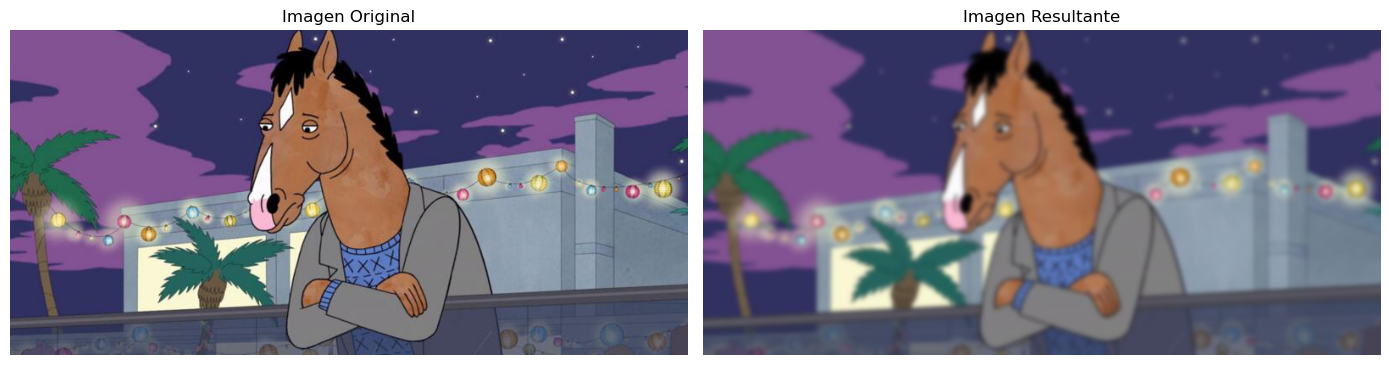

In [13]:
import cv2
from matplotlib import pyplot as plt

# 1. Definir la ruta de tu imagen usando una 'r' al principio (raw string)
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\caballo.jpg'  # Cambia esta ruta a tu imagen

img = cv2.imread(ruta, 1)

if img is None:
    print(f"Error: No se encontró la imagen en: {ruta}")
    print("Asegúrate de que la extensión (.jpeg) y la carpeta sean correctas.")
else:
   
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

   
    img_blur = cv2.GaussianBlur(img_rgb, (15, 15), 0)

    # 4. Mostrar los resultados lado a lado
    plt.figure(figsize=(14, 7))

    # Lado izquierdo: Original
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Imagen Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_blur)
    plt.title('Imagen Resultante')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

pregunta 3

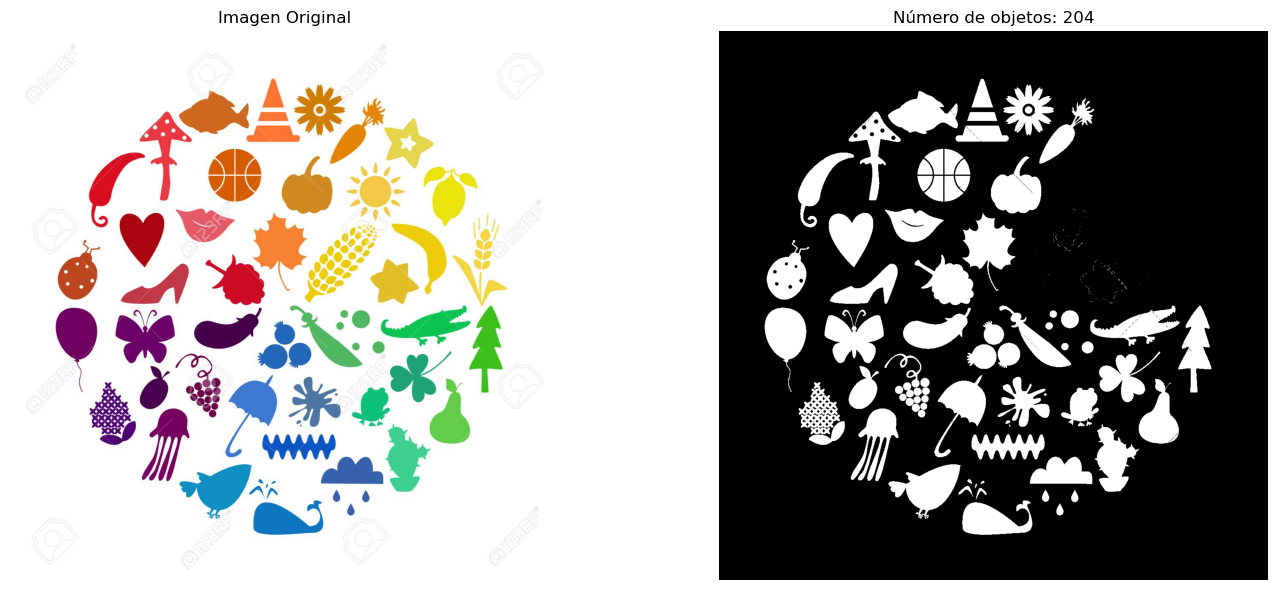

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\elementos.jpg'  

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binario = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, 1))
    limpio = cv2.morphologyEx(binario, cv2.MORPH_CLOSE, kernel, iterations=1)
    limpio = cv2.dilate(limpio, kernel, iterations=2)
    limpio = cv2.erode(limpio, kernel, iterations=1)
    
    
    num_labels, labels = cv2.connectedComponents(limpio)
    num_obj = num_labels + 1
    return num_obj, limpio

elementos = cv2.imread(ruta)
num_obj, binario = contar_elementos(elementos)


elementos_rgb = cv2.cvtColor(elementos, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(elementos_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binario, cmap='gray')
plt.title(f'Número de objetos: {num_obj}')
plt.axis('off')

plt.tight_layout()
plt.show()

ejercicio 5

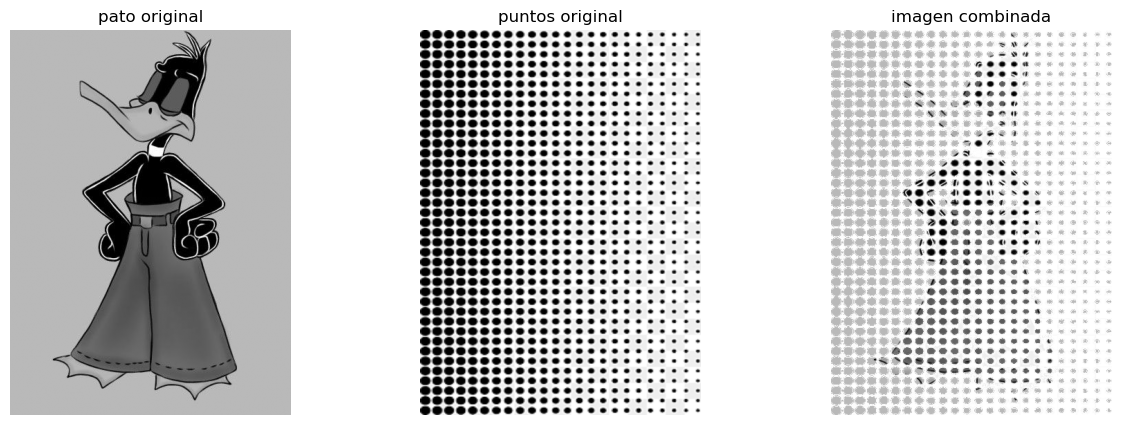

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos las rutas correctamente (Corregido a puntos.png)
ruta_pato = r'D:\UNIVALLE\PDY\unidad 1\clases\img\pato.jpg'
ruta_puntos = r'D:\UNIVALLE\PDY\unidad 1\clases\img\puntos.png'

# 2. Cargamos las imágenes usando las variables de ruta
pato = cv2.imread(ruta_pato, 0)
puntos = cv2.imread(ruta_puntos, 0)

# Verificación de seguridad
if pato is None or puntos is None:
    raise FileNotFoundError("¡Ups! No se pudo cargar una de las imágenes. Revisa que las rutas sean correctas.")

# 3. Redimensionamos y aplicamos los filtros
puntos_resized = cv2.resize(puntos, (pato.shape[1], pato.shape[0]))
mask = cv2.bitwise_or(pato, puntos_resized)
blur = cv2.GaussianBlur(pato, (21, 21), 0)
mask_blur = cv2.bitwise_or(blur, puntos_resized)

# 4. Mostramos los resultados (Corregido 'pll' por 'plt')
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(pato, cmap='gray')
plt.title('pato original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(puntos_resized, cmap='gray')
plt.title('puntos original')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask, cmap='gray')
plt.title('imagen combinada')
plt.axis('off')

plt.show()